✓ Loaded data from: ../processed/full_processed.csv
Dataset shape: (40432, 22)
Columns: ['category', 'rating', 'label', 'text', 'text_clean', 'text_tfidf', 'label_encoded', 'char_count', 'word_count', 'avg_word_length', 'caps_ratio', 'exclamation_count', 'question_count', 'punct_ratio', 'unique_word_ratio', 'sentence_count', 'avg_sentence_length', 'first_person_ratio', 'sentiment_polarity', 'sentiment_subjectivity', 'rating_normalized', 'star_sentiment_gap']
<class 'pandas.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   category                40432 non-null  str    
 1   rating                  40432 non-null  float64
 2   label                   40432 non-null  str    
 3   text                    40432 non-null  str    
 4   text_clean              40432 non-null  str    
 5   text_tfidf              40431 non-null  str    
 6   label_enco

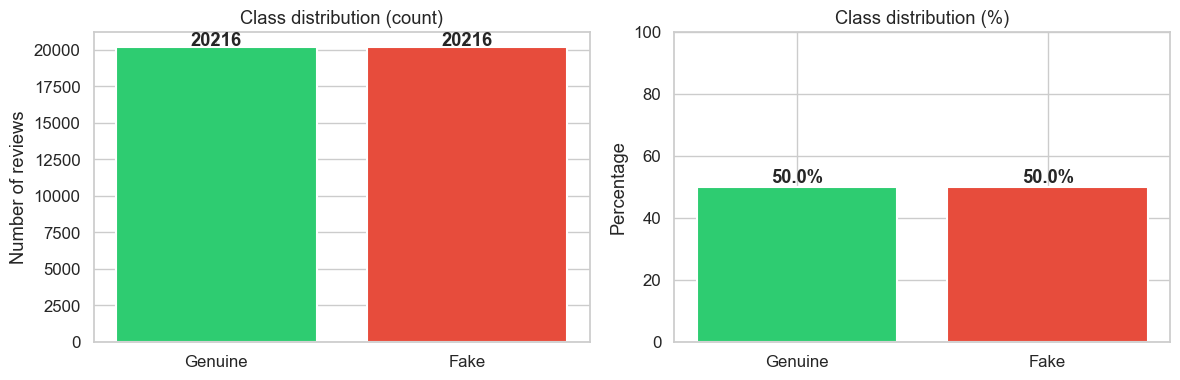


Genuine: 20216 | Fake: 20216 | Ratio: 1.00:1


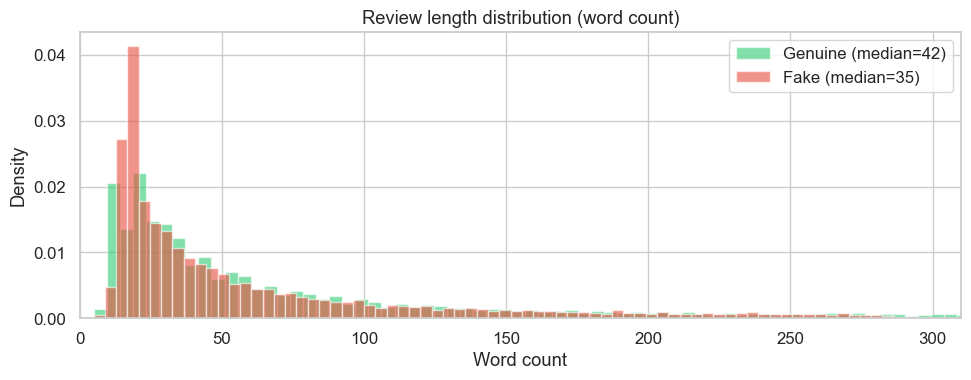

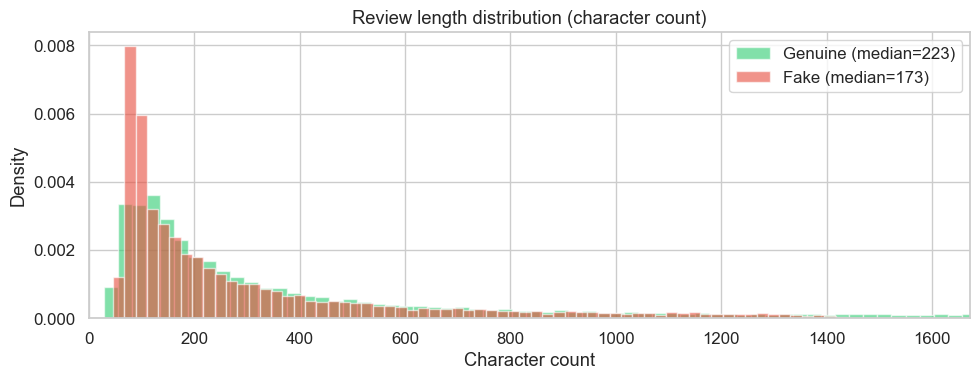

Feature                   Genuine (mean±std)        Fake (mean±std)           Diff      
-------------------------------------------------------------------------------------
char_count                393.272 ± 412.196         302.661 ± 304.470         -90.611
word_count                73.594 ± 75.998           61.256 ± 61.809           -12.337
avg_word_length           5.316 ± 0.462             4.997 ± 0.648             -0.318
caps_ratio                0.030 ± 0.051             0.031 ± 0.044             +0.001
exclamation_count         0.519 ± 1.515             0.276 ± 1.248             -0.244
question_count            0.095 ± 0.498             0.011 ± 0.163             -0.083
punct_ratio               0.030 ± 0.015             0.029 ± 0.017             -0.001
unique_word_ratio         0.825 ± 0.122             0.750 ± 0.174             -0.075
sentence_count            6.212 ± 4.799             6.354 ± 5.891             +0.142
avg_sentence_length       10.804 ± 5.741            9.561 

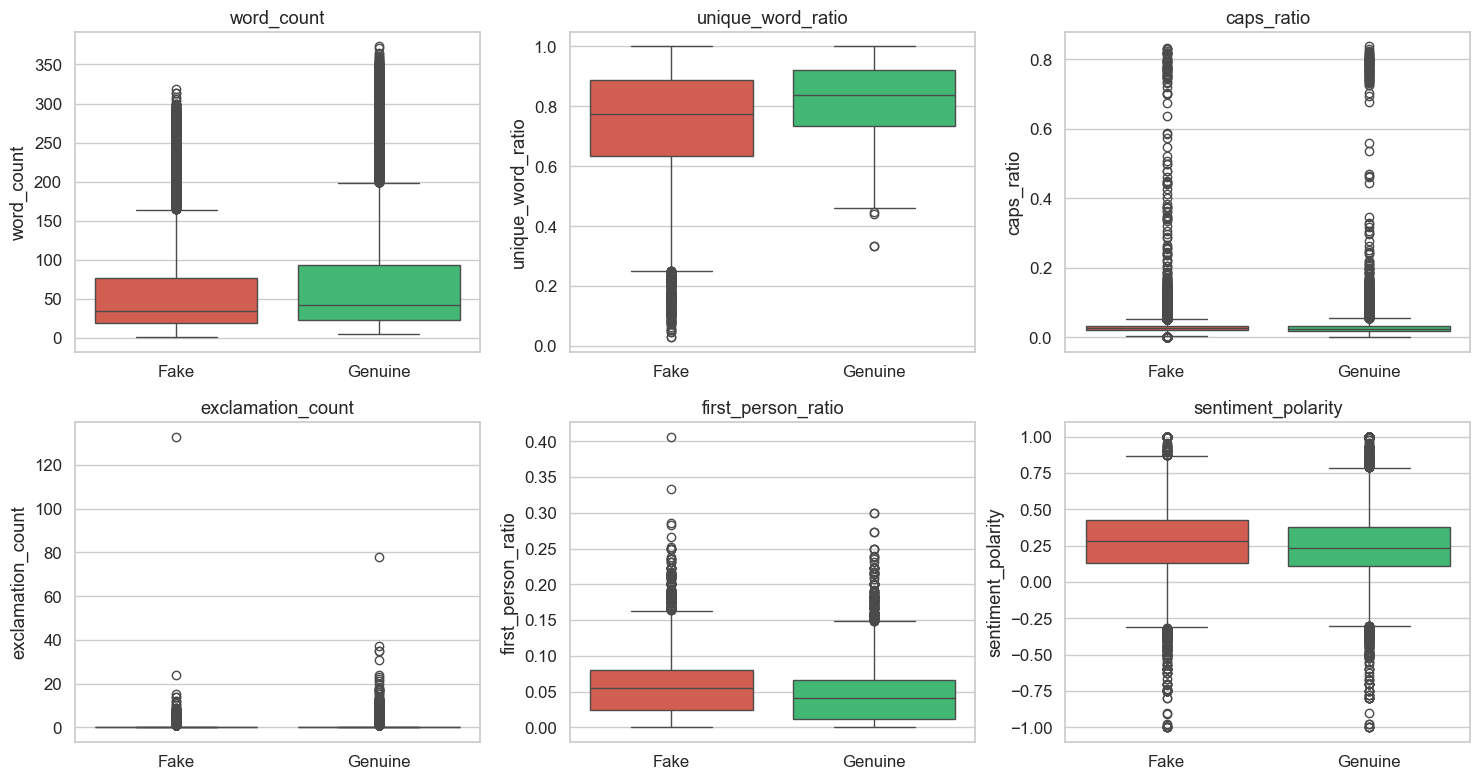

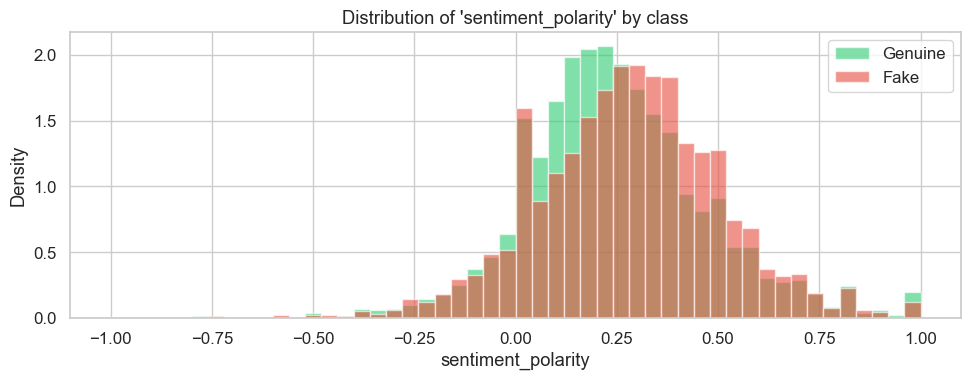

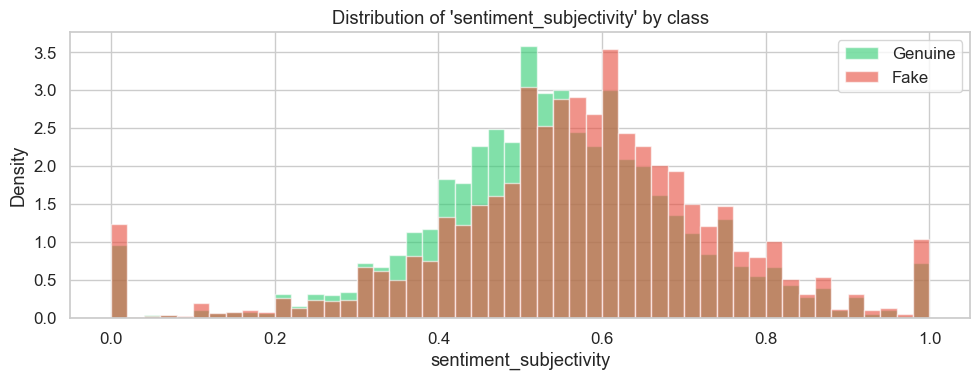

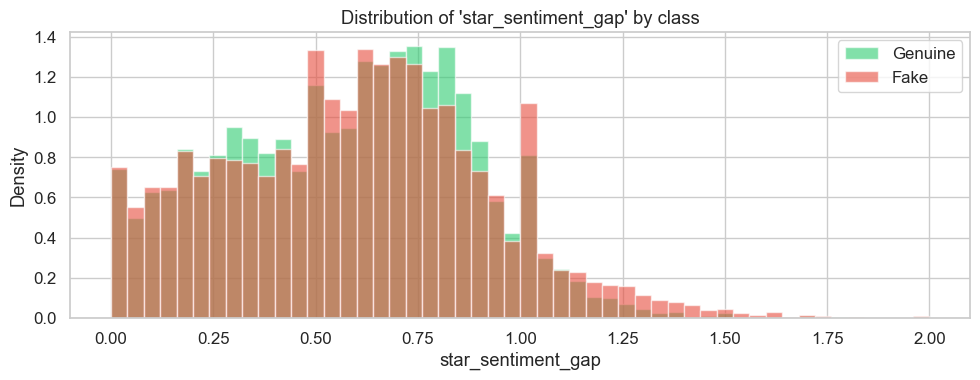

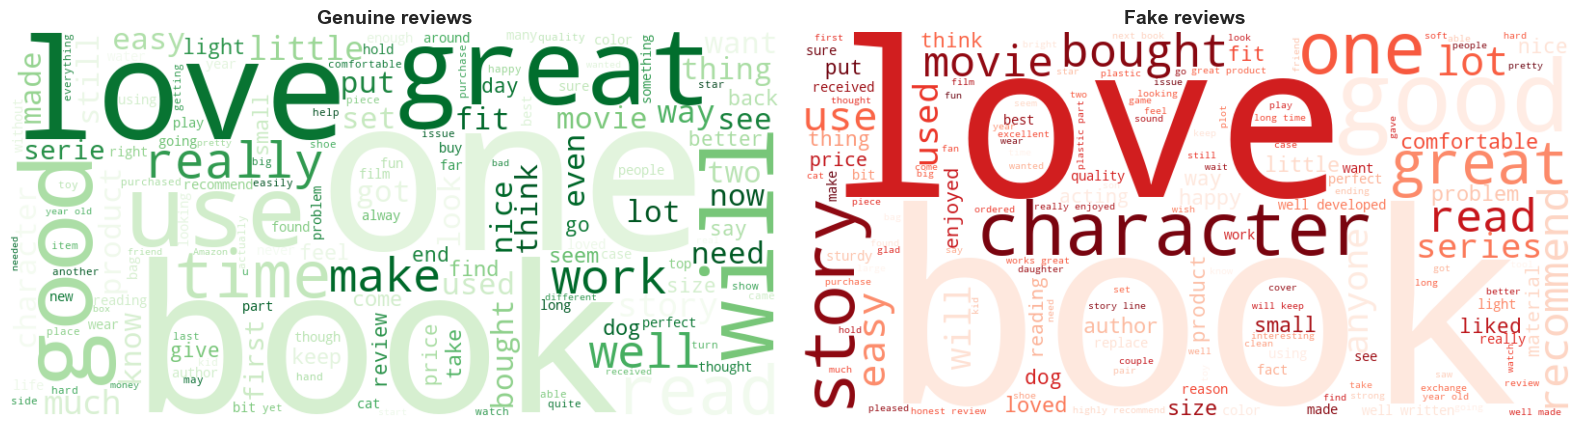

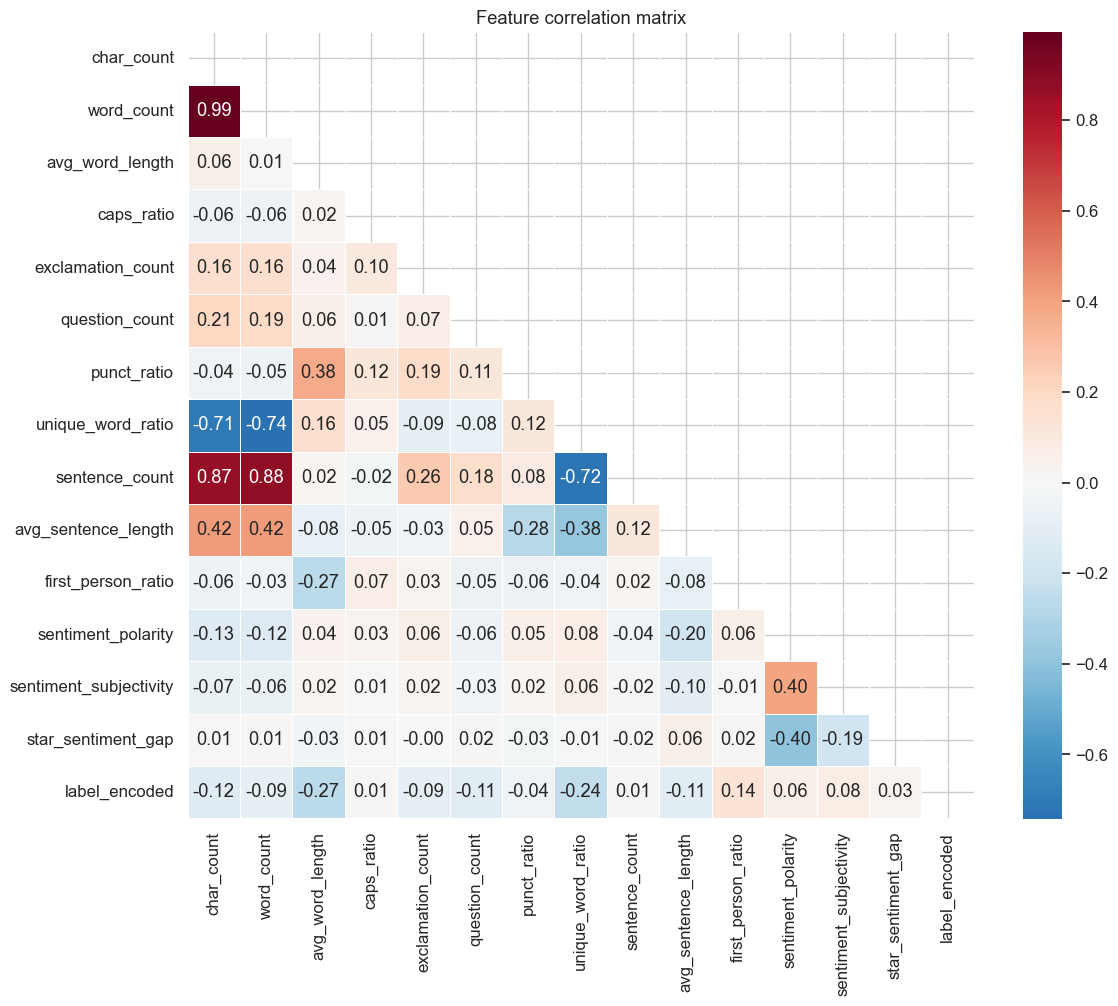

Feature importance (absolute correlation with label):

  avg_word_length           0.272  █████████████  (↑ genuine)
  unique_word_ratio         0.241  ████████████  (↑ genuine)
  first_person_ratio        0.137  ██████  (↑ fake)
  char_count                0.124  ██████  (↑ genuine)
  avg_sentence_length       0.112  █████  (↑ genuine)
  question_count            0.112  █████  (↑ genuine)
  word_count                0.089  ████  (↑ genuine)
  exclamation_count         0.088  ████  (↑ genuine)
  sentiment_subjectivity    0.076  ███  (↑ fake)
  sentiment_polarity        0.062  ███  (↑ fake)
  punct_ratio               0.038  █  (↑ genuine)
  star_sentiment_gap        0.025  █  (↑ fake)
  sentence_count            0.013    (↑ fake)
  caps_ratio                0.012    (↑ fake)
Fake review ratio by category:

                              total_reviews  fake_ratio  fake_ratio_pct
category                                                               
Books_5                               

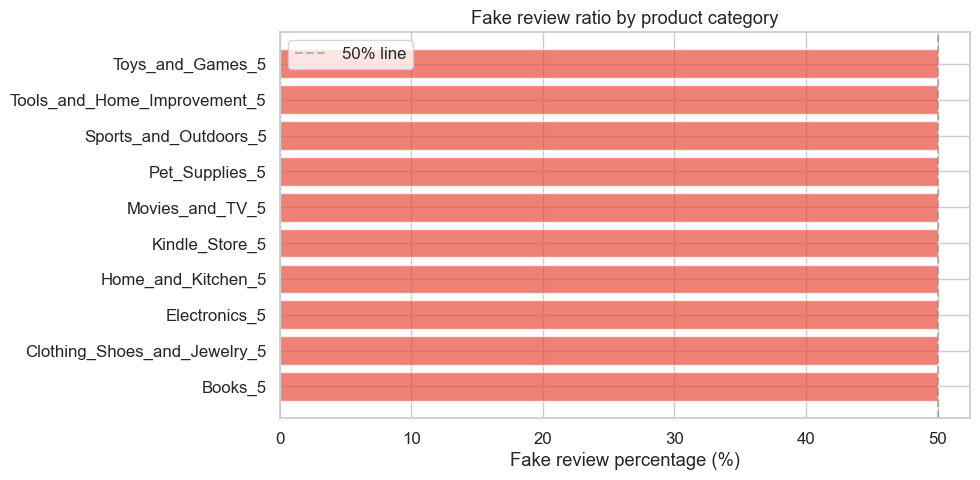

Split    Rows   Genuine      Fake   Genuine%    Fake%
-------------------------------------------------------
train   28302     14151     14151      50.0%    50.0%
  val    6065      3032      3033      50.0%    50.0%
 test    6065      3033      3032      50.0%    50.0%


In [1]:
# %% [markdown]
# # Genzon — Exploratory Data Analysis
#
# Just run each cell top to bottom. Everything is self-contained.

# %%
# ── Setup: Install anything missing ──
import subprocess, sys

for pkg in ["wordcloud", "textblob", "seaborn", "matplotlib", "pandas"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# %%
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# %%
# ── Load data ──
# Try multiple possible paths (works whether you run from notebooks/, data/, or project root)
possible_paths = [
    Path("../processed/full_processed.csv"),          # from data/notebooks/
    Path("data/processed/full_processed.csv"),         # from project root
    Path("processed/full_processed.csv"),              # from data/
    Path("../../data/processed/full_processed.csv"),   # from nested folders
]

df = None
for p in possible_paths:
    if p.exists():
        df = pd.read_csv(p)
        print(f"✓ Loaded data from: {p}")
        break

if df is None:
    raise FileNotFoundError(
        "Could not find full_processed.csv!\n"
        "Make sure you ran: python -m data.preprocess --no-smote"
    )

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

# %%
df.info()

# %%
df.describe()

# %%
# ── Constants ──
LABEL_COL = "label_encoded"
LABEL_MAP = {0: "Genuine", 1: "Fake"}
COLORS = {"Genuine": "#2ecc71", "Fake": "#e74c3c"}

NUMERIC_FEATURES = [
    "char_count", "word_count", "avg_word_length", "caps_ratio",
    "exclamation_count", "question_count", "punct_ratio",
    "unique_word_ratio", "sentence_count", "avg_sentence_length",
    "first_person_ratio", "sentiment_polarity", "sentiment_subjectivity",
    "star_sentiment_gap",
]

# Only keep features that actually exist in our dataframe
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in df.columns]
print(f"Available numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")

# %% [markdown]
# ## 1. Class Distribution
# Is the dataset balanced (50/50) or imbalanced?

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[LABEL_COL].value_counts().sort_index()
labels = [LABEL_MAP[i] for i in counts.index]
colors = [COLORS[l] for l in labels]

# Count
axes[0].bar(labels, counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Class distribution (count)")
axes[0].set_ylabel("Number of reviews")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Percentage
pcts = counts.values / counts.values.sum() * 100
axes[1].bar(labels, pcts, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Class distribution (%)")
axes[1].set_ylabel("Percentage")
axes[1].set_ylim(0, 100)
for i, v in enumerate(pcts):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

n_genuine = counts.get(0, 0)
n_fake = counts.get(1, 0)
print(f"\nGenuine: {n_genuine} | Fake: {n_fake} | Ratio: {n_genuine/max(n_fake,1):.2f}:1")

# %% [markdown]
# ## 2. Review Length Analysis
# Fake reviews tend to be shorter or unnaturally uniform.

# %%
fig, ax = plt.subplots(figsize=(10, 4))

for label_val, label_name in LABEL_MAP.items():
    subset = df[df[LABEL_COL] == label_val]["word_count"].dropna()
    ax.hist(
        subset, bins=80, alpha=0.6,
        label=f"{label_name} (median={subset.median():.0f})",
        color=COLORS[label_name], density=True,
    )

ax.set_title("Review length distribution (word count)")
ax.set_xlabel("Word count")
ax.set_ylabel("Density")
ax.set_xlim(0, df["word_count"].quantile(0.99))
ax.legend()
plt.tight_layout()
plt.show()

# %%
# Character count distribution
fig, ax = plt.subplots(figsize=(10, 4))

for label_val, label_name in LABEL_MAP.items():
    subset = df[df[LABEL_COL] == label_val]["char_count"].dropna()
    ax.hist(
        subset, bins=80, alpha=0.6,
        label=f"{label_name} (median={subset.median():.0f})",
        color=COLORS[label_name], density=True,
    )

ax.set_title("Review length distribution (character count)")
ax.set_xlabel("Character count")
ax.set_ylabel("Density")
ax.set_xlim(0, df["char_count"].quantile(0.99))
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Text Feature Comparison (Fake vs Genuine)
# Table showing mean ± std for each feature.

# %%
print(f"{'Feature':<25} {'Genuine (mean±std)':<25} {'Fake (mean±std)':<25} {'Diff':<10}")
print("-" * 85)

for feat in NUMERIC_FEATURES:
    genuine = df[df[LABEL_COL] == 0][feat]
    fake = df[df[LABEL_COL] == 1][feat]

    g_str = f"{genuine.mean():.3f} ± {genuine.std():.3f}"
    f_str = f"{fake.mean():.3f} ± {fake.std():.3f}"
    diff = fake.mean() - genuine.mean()
    sign = "+" if diff > 0 else ""
    print(f"{feat:<25} {g_str:<25} {f_str:<25} {sign}{diff:.3f}")

# %% [markdown]
# ## 4. Feature Boxplots
# Visual comparison of key features between classes.

# %%
key_features = [
    "word_count", "unique_word_ratio", "caps_ratio",
    "exclamation_count", "first_person_ratio", "sentiment_polarity",
]
# Only keep features that exist
key_features = [f for f in key_features if f in df.columns]

n = len(key_features)
cols = min(3, n)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, feat in enumerate(key_features):
    df_plot = df[[feat, LABEL_COL]].copy()
    df_plot["Class"] = df_plot[LABEL_COL].map(LABEL_MAP)

    sns.boxplot(
        data=df_plot, x="Class", y=feat,
        hue="Class", palette=COLORS, legend=False,
        ax=axes[i],
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel("")

# Hide empty subplots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Sentiment Analysis
# Genuine reviews should have sentiment aligned with their rating.
# Fakes may show extremes or mismatches.

# %%
sentiment_features = ["sentiment_polarity", "sentiment_subjectivity", "star_sentiment_gap"]
sentiment_features = [f for f in sentiment_features if f in df.columns]

for feat in sentiment_features:
    fig, ax = plt.subplots(figsize=(10, 4))
    for label_val, label_name in LABEL_MAP.items():
        subset = df[df[LABEL_COL] == label_val][feat].dropna()
        ax.hist(
            subset, bins=50, alpha=0.6,
            label=label_name, color=COLORS[label_name], density=True,
        )
    ax.set_title(f"Distribution of '{feat}' by class")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 6. Word Clouds
# Most common words in fake vs genuine reviews.

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label_val, label_name) in zip(axes, LABEL_MAP.items()):
    text = " ".join(df[df[LABEL_COL] == label_val]["text_clean"].dropna().astype(str))

    if len(text.strip()) == 0:
        ax.set_title(f"{label_name} reviews — no text found")
        ax.axis("off")
        continue

    wc = WordCloud(
        width=800, height=400, background_color="white",
        colormap="Greens" if label_name == "Genuine" else "Reds",
        max_words=150,
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label_name} reviews", fontsize=14, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Feature Correlation Heatmap
# Which features correlate with fake/genuine label?

# %%
corr_cols = NUMERIC_FEATURES + [LABEL_COL]
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    square=True, linewidths=0.5,
)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. Top Discriminative Features
# Ranked by how strongly they correlate with the fake/genuine label.

# %%
label_corrs = df[NUMERIC_FEATURES + [LABEL_COL]].corr(numeric_only=True)[LABEL_COL].drop(LABEL_COL)
label_corrs_sorted = label_corrs.abs().sort_values(ascending=False)

print("Feature importance (absolute correlation with label):\n")
for feat, val in label_corrs_sorted.items():
    direction = "↑ fake" if label_corrs[feat] > 0 else "↑ genuine"
    bar = "█" * int(val * 50)
    print(f"  {feat:<25} {val:.3f}  {bar}  ({direction})")

# %% [markdown]
# ## 9. Category Analysis
# Check if fake reviews cluster in certain product categories.

# %%
if "category" in df.columns:
    cat_stats = df.groupby("category")[LABEL_COL].agg(["count", "mean"])
    cat_stats.columns = ["total_reviews", "fake_ratio"]
    cat_stats["fake_ratio_pct"] = (cat_stats["fake_ratio"] * 100).round(1)
    cat_stats = cat_stats.sort_values("fake_ratio", ascending=False)
    print("Fake review ratio by category:\n")
    print(cat_stats.to_string())

    # Plot
    fig, ax = plt.subplots(figsize=(10, max(4, len(cat_stats) * 0.5)))
    bars = ax.barh(cat_stats.index, cat_stats["fake_ratio_pct"], color="#e74c3c", alpha=0.7)
    ax.axvline(x=50, color="gray", linestyle="--", alpha=0.5, label="50% line")
    ax.set_xlabel("Fake review percentage (%)")
    ax.set_title("Fake review ratio by product category")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 'category' column found — skipping.")

# %% [markdown]
# ## 10. Train/Val/Test Split Verification

# %%
# Find the processed directory
processed_dir = None
for p in [Path("../processed"), Path("data/processed"), Path("processed"), Path("../../data/processed")]:
    if p.exists():
        processed_dir = p
        break

if processed_dir:
    print(f"{'Split':>5}  {'Rows':>6}  {'Genuine':>8}  {'Fake':>8}  {'Genuine%':>9}  {'Fake%':>7}")
    print("-" * 55)

    for split in ["train", "val", "test"]:
        path = processed_dir / f"{split}.csv"
        if path.exists():
            split_df = pd.read_csv(path)
            dist = split_df[LABEL_COL].value_counts()
            total = len(split_df)
            g = dist.get(0, 0)
            f = dist.get(1, 0)
            print(f"{split:>5}  {total:>6}  {g:>8}  {f:>8}  {g/total*100:>8.1f}%  {f/total*100:>6.1f}%")
        else:
            print(f"{split:>5}  — file not found")
else:
    print("Processed directory not found. Make sure you ran preprocess.py first.")

# %% [markdown]
# ## Summary
#
# Fill these in after reviewing the plots above:
#
# - **Class balance**: ~50/50 → SMOTE not needed for this dataset
# - **Most discriminative features**: (check section 8 output)
# - **Review length patterns**: (check section 2 — are fakes shorter?)
# - **Sentiment patterns**: (check section 5 — do fakes show mismatches?)
# - **Category patterns**: (check section 9 — any category with more fakes?)
# - **Next step**: Phase 2 — ML Model (rule engine + BERT)